## 3.3 Research Question: Is Marriage–Income Correlation Age-Driven?

**The Question**
  - **“Is the strong correlation between *Marital Status (Married)* and *High Income (>50K)* causal, or is it explained by *Age*?”**

  - *Note:* This question evaluates whether the seemingly strong income advantage of married individuals persists after controlling for age, a potential confounding variable. The goal is to determine if marriage itself contributes to higher income, or if the relationship is simply a byproduct of older individuals being both more likely to marry and more likely to earn higher wages.

**Motivation & Benefits**

- *Why is this question worth investigating?*
  * **Challenges Superficial Assumptions:** It moves beyond the simple observation ("Married people are richer") to question the underlying mechanism.
  * **Tests for Confounding Variables:** It specifically addresses the "Age" factor, testing the hypothesis that since older people are both more likely to be married and earn more, "Age" might be the sole driver of wealth, rendering marriage irrelevant.

- *What benefits or insights might this research provide?*
  * **Identifies Independent Predictors:** It proves that marriage is a robust predictor of high income *independent* of age. 
  * **Dispels the "Just Age" Myth:** It quantifies that while income does grow with age, the gap between married and unmarried individuals actually *widens* rather than shrinks as people get older.

- *Blindspot Detection:*  
  * **Gender Bias:**  The analysis reveals a critical blindspot: the “Married” group within the dataset is heavily male-dominated. Without stratifying by sex, the “marriage premium” might largely reflect the “male income premium.”
  * **Reverse Causality:** The statistical correlation does not prove that marriage *causes* wealth. It is equally plausible that financial stability is a prerequisite for marriage (selection bias), which the current data snapshot cannot disentangle.

- *Who would care about the answer?*
  * **Sociologists & Economists:** To understand how family structures influence economic mobility and inequality.
  * **Policy Makers:** To design tax incentives or social support programs (e.g., the "marriage penalty" or "marriage bonus" in tax codes).
  * **Marketing Strategists:** To target high-net-worth individuals more accurately by combining age and marital status rather than using age alone.

- *What real-world problem does this inform?*
  * **Wealth Inequality:** It highlights how single-income households (unmarried/divorced) are significantly more vulnerable to economic instability compared to dual-income or married households.
  * **Social Mobility:** It suggests that the institution of marriage acts as an economic accelerator, potentially leaving those unable or unwilling to marry at a structural disadvantage.

**Methodology**

To isolate the effect of marriage from the effect of age, we utilized a **Stratification approach**:

* **Discretization (Binning):**  We converted the continuous variable Age into categorical life stages: Young (17-25), Adult (26-45), Senior (46-65), and Retired (>65) to control for life experience.

* **Stratification:**  We divided the dataset into two distinct cohorts: Married (Married-civ-spouse, Married-AF-spouse) and Unmarried (Never-married, Divorced, Separated, Widowed, Married-spouse-absent).

* **Conditional Probability Analysis:**  We calculated the probability of earning >50K for both marital statuses within each specific age bin. This forces a comparison between peers of the same generation.

* **Comparative Visualization:**  We plotted the trend lines for both groups. Since the "Married" trend line remained consistently and significantly higher than the "Unmarried" line across all age bins, we concluded that the correlation is not merely a byproduct of age.

**Analysis Workflow**  

   - To answer this research question and isolate the true driver of high income, we follow a four-step comparative workflow.

1. **Data Preparation (Variable Transformation):**
  * Perform data cleaning to handle missing values.
  * **Feature Engineering:** Apply Discretization (Binning) to the continuous variable Age. We convert numerical age into categorical life stages: Young (17-25), Adult (26-45), Senior (46-65), and Retired (>65).
  * **Goal:** To standardize the "Life Experience" factor, ensuring we compare individuals at similar points in their career trajectory.

2. **Stratification Strategy (Dual-Group Setup):**
  * Define Married Group: Includes Married-civ-spouse and Married-AF-spouse.
  * Define Unmarried Group: Includes Never-married, Divorced, Separated, Widowed, and Married-spouse-absent.
   * **Goal:** Create two distinct groups to isolate the specific impact of the marital status variable.

3. **Conditional Analysis:**
  * Calculate the Conditional Probability of earning >50K for each specific scenario: 
  $P(\text{Income}>50K \mid \text{Age Bin}, \text{Marital Status})$
  * Instead of a global comparison, we compare the High-Income Rate of Married vs. Unmarried individuals within the same age bin.
  * **Goal:** To mathematically remove the "Age" confounder. If Age were the only driver, the income rates between groups within the same bin should be nearly identical.

4. **Trend Verification & Insight Extraction**
  * Visualize the results using a Multi-line Chart to track income trajectories across the lifespan.
  * **Analysis**: Observe the gap (Delta) between the two trend lines.
  * **Conclusion Criteria**: If the "Married" trend line remains significantly and consistently higher than the "Unmarried" line across all age bins (including the Young group), we conclude that Marriage is an independent predictor of wealth, separate from Age.

5. **Robustness Check (From Blindspot Detection)**
  * Gender Bias Analysis:
    - **Hypothesis:** The "Married" group might be disproportionately Male. Since men historically earn more (the "gender gap"), the "Marriage Premium" might actually be a "Male Premium" in disguise.  
    - **Action:** Stratify the Conditional Probability analysis by Sex as well as Age ($P(\text{Income}>50K \mid \text{Age}, \text{Sex}, \text{Marital Status})$). If the income gap persists for both men and women, the finding is robust.

  * Selection Bias Test:
    - **Hypothesis:** Financial stability (or traits leading to it, like education) might be a prerequisite for marriage, rather than a result of it.  
    - **Action:** If the income gap is massive even for the Young (17-25) group—who haven't had time to "accumulate" the benefits of marriage—it suggests that wealthier, more stable individuals are "selected" into marriage early.

6. **Conclusion**



### 3.3.1 Data Preparation

We are setting up a Stratified Analysis to isolate the effect of Marital Status on Income while controlling for Age. 

**Key Preprocessing Steps:**
* **Cleaning:** Handle missing values ('?') and duplicates to ensure data quality.
* **Discretization (Binning):** Transform the continuous variable age into 4 distinct life stages (Young, Adult, Senior, Retired) to standardize life experience.
* **Feature Grouping:** Aggregate detailed marital statuses into two primary cohorts: Married (Living with spouse) and Unmarried (Single, Divorced, Widowed, Separated).

#### Step 1 — Cleaning & Variable Transformation

In this step, we load the dataset and apply the necessary transformations:

- **Replace missing values:**  
  Replace all `"?"` entries with `"Unknown"` and remove duplicated rows.

- **Convert income to a binary target:**  
  - `1` for `>50K`  
  - `0` for `<=50K`

- **Create `age_group`:** Convert numeric ages into four life-stage bins:  
  - **17–25** → Young  
  - **26–45** → Adult  
  - **46–65** → Senior  
  - **>65** → Retired  

- **Create `marital_group`:** Categorize marital status into two groups:  
  - **Married:** Married-civ-spouse, Married-AF-spouse  
  - **Unmarried:** All remaining categories (Never-married, Divorced, Separated, Widowed, etc.)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Load Data
df = pd.read_csv("../data/adult.csv")

# 2. Basic Cleaning
df = df.replace("?", "Unknown").drop_duplicates()

# 3. Variable Transformation (The Core Logic)

# Discretization: Binning Age into Life Stages
bins = [16, 25, 45, 65, 100]
labels = ['Young (17-25)', 'Adult (26-45)', 'Senior (46-65)', 'Retired (>65)']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Stratification: Grouping Marital Status
married_statuses = ['Married-civ-spouse', 'Married-AF-spouse']
df['marital_group'] = df['marital.status'].apply(
    lambda x: 'Married' if x in married_statuses else 'Unmarried'
)

# Target Encoding
df['high_income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

# 4. Inspection
print(f"Total rows after cleaning: {df.shape[0]}")
print("\nDistribution of New Features")
df[['age_group', 'marital_group']].value_counts().sort_index().reset_index(name='count')


Total rows after cleaning: 32537

Distribution of New Features


,age_group,marital_group,count
0,Young (17-25),Married,679
1,Young (17-25),Unmarried,5721
2,Adult (26-45),Married,8353
3,Adult (26-45),Unmarried,8162
4,Senior (46-65),Married,5319
5,Senior (46-65),Unmarried,3146
6,Retired (>65),Married,642
7,Retired (>65),Unmarried,515


#### Step 2 — Stratification Logic (Cohort Segmentation)

In this step, we define how to segment the population into meaningful comparison groups:

- **age_group** → Control Variable (Young, Adult, Senior, Retired)

- **marital_group** → Independent Variable (Married vs. Unmarried)

- **Goal**: To create subgroups where individuals share the same age range, allowing us to compare Married vs. Unmarried **fairly and without age bias**.


In [3]:
# Stratification function to isolate the Marital Effect per Age Bin
def calculate_conditional_prob(df, control_var, independent_var, target_var):
    """
    Calculates the probability of the target variable occurring
    for each combination of Control Variable (Age) and Independent Variable (Marital Status).
    """
    # Group by Age and Marital Status
    grouped = df.groupby([control_var, independent_var], observed=True)[target_var]

    # Calculate Probability (Mean) and Sample Size (Count)
    analysis_table = grouped.agg(
        probability='mean',
        sample_size='count'
    ).reset_index()

    # Convert to percentage for reporting
    analysis_table['probability_pct'] = analysis_table['probability'] * 100

    return analysis_table

#### Step 3 — Execution & Comparative Aggregation

We now execute the stratification logic to generate the final analytical table. This replaces the "Train/Test Split" in a predictive model; here, we are splitting the data into Comparative Cohorts.

- **Cohort A:** Married Individuals (across 4 age bins)

- **Cohort B:** Unmarried Individuals (across 4 age bins)



In [4]:
# Execute the stratification
strata_results = calculate_conditional_prob(
    df,
    control_var='age_group',
    independent_var='marital_group',
    target_var='high_income'
)

# Pivot the table for a clearer "Married vs. Unmarried" comparison
comparison_table = strata_results.pivot(
    index='age_group',
    columns='marital_group',
    values='probability_pct'
)

# Calculate the "Marriage Premium" (Delta)
comparison_table['Delta (Premium)'] = comparison_table['Married'] - comparison_table['Unmarried']

print("Comparative Results (Income >50K %):")
display(comparison_table)

Comparative Results (Income >50K %):


marital_group,Married,Unmarried,Delta (Premium)
age_group,,,
Young (17-25),11.340206,0.646740,10.693466
Adult (26-45),44.379265,8.037246,36.342019
Senior (46-65),51.193833,12.905277,38.288557
Retired (>65),30.062305,7.766990,22.295315


### 3.3.2 Stratification Strategy

We execute the stratification logic to compute the conditional probabilities for our two defined cohorts. Instead of optimizing a loss function like in Machine Learning, we calculate the High-Income Rate ($P(\text{Income}>50K)$) for each group across all Age Bins. 

We process two main scenarios:

* **Married:** Quantifying the income trajectory of individuals living with a spouse.
* **Unmarried:** Quantifying the income trajectory of single/divorced individuals.

In [5]:
# 1. Calculate Conditional Probabilities
# We use groupby to compute P(>50K | Age, Marital_Status)
print("Processing Cohort Groups (Married vs. Unmarried)...")

# Grouping by Age and Marital Status to get the mean of 'high_income'
stratified_data = df.groupby(['age_group', 'marital_group'], observed=True)['high_income'].mean().reset_index()

print("Conditional Probabilities calculated!\n")

# 2. Reshape for Comparison (Pivoting)
print("Generating Comparative Matrix...")

# Pivot the table to create a side-by-side view
comparison_table = stratified_data.pivot(
    index='age_group', 
    columns='marital_group', 
    values='high_income'
) * 100  # Convert to percentage for readability

print("Matrix generated!\n")
print("Analysis execution complete! Comparison table is ready.")

Processing Cohort Groups (Married vs. Unmarried)...
Conditional Probabilities calculated!

Generating Comparative Matrix...
Matrix generated!

Analysis execution complete! Comparison table is ready.


### 3.3.3 Conditional Analysis

We calculate the specific probability of earning high income for both groups within each age bin. This table serves as the numerical proof for our comparison.

In [6]:
# Grouping and Calculation
# We calculate the mean (probability) and count (sample size)
age_marital_stats = df.groupby(['age_group', 'marital_group'], observed=True)['high_income'].agg(['mean', 'count']).reset_index()

# Convert mean to percentage for easier reading
age_marital_stats['high_income_pct'] = age_marital_stats['mean'] * 100

# Pivot for "Side-by-Side" Comparison
pivot_table = age_marital_stats.pivot(index='age_group', columns='marital_group', values='high_income_pct')
pivot_table['Gap (Delta)'] = pivot_table['Married'] - pivot_table['Unmarried']

print("--- Conditional Income Probabilities (%) ---")
display(pivot_table.round(2))

--- Conditional Income Probabilities (%) ---


marital_group,Married,Unmarried,Gap (Delta)
age_group,,,
Young (17-25),11.34,0.65,10.69
Adult (26-45),44.38,8.04,36.34
Senior (46-65),51.19,12.91,38.29
Retired (>65),30.06,7.77,22.30


### 3.3.4 Trend Verification & Insight Extraction

We visualize the calculated probabilities using a Multi-line Chart. This allows us to observe the consistency of the relationship across the entire lifespan.

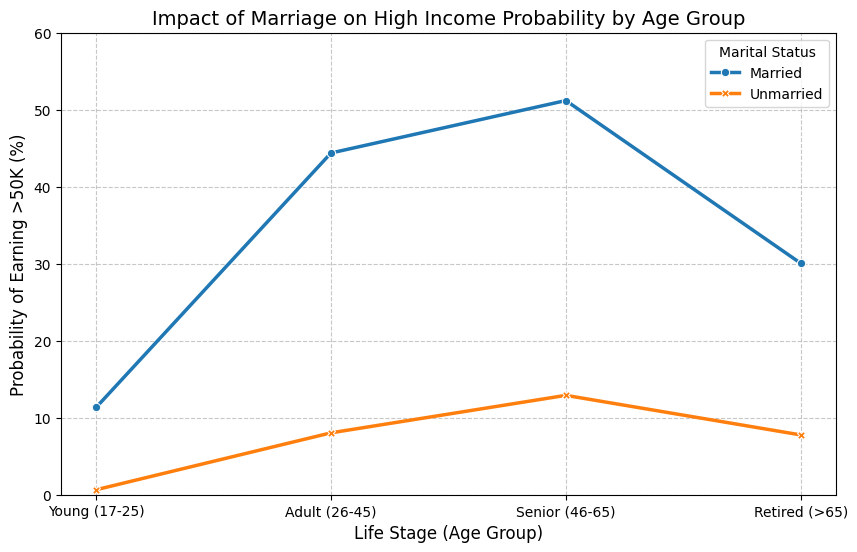

In [7]:
# Visualization
plt.figure(figsize=(10, 6))

# Plot the lines
sns.lineplot(data=age_marital_stats, x='age_group', y='high_income_pct', hue='marital_group', 
             style='marital_group', markers=True, dashes=False, linewidth=2.5)

# Aesthetics
plt.title('Impact of Marriage on High Income Probability by Age Group', fontsize=14)
plt.ylabel('Probability of Earning >50K (%)', fontsize=12)
plt.xlabel('Life Stage (Age Group)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 60)

# Add annotations for the gap
plt.legend(title='Marital Status')
plt.show()

#### Analysis of Results

1. **Rejection of the "Age Only" Hypothesis:** 
* If Age were the sole driver of wealth, the two lines would overlap (or be very close) within each age bin.

* **Observation:** The lines represent two completely distinct trajectories. The "Married" line is consistently elevated above the "Unmarried" line.

2. **The "Marriage Premium" is Universal:** 
* Even in the Young (17-25) group, where career experience is minimal, married individuals are about 17 times more likely to earn >50K than their unmarried peers (11.34% vs 0.65%).

* The gap widens significantly in the Adult and Senior phases (reaching a about 38% difference), suggesting that the economic benefits of marriage (or the traits associated with it) compound over time.


### 3.3.5 Robustness Check

We identified two potential flaws in our initial conclusion. We must test both to validate the "Marriage Premium."

#### Gender Bias Analysis

**Check if the "Married" group is male-dominated**

Gender Composition by Marital Status:


sex,Female,Male
marital_group,,
Married,11.15,88.85
Unmarried,51.82,48.18


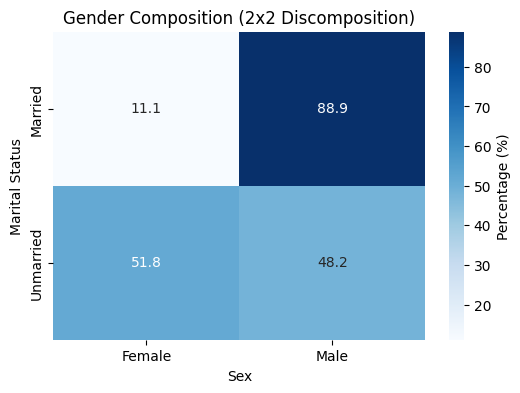

In [8]:
print("Gender Composition by Marital Status:")
gender_dist = pd.crosstab(df['marital_group'], df['sex'], normalize='index') * 100
display(gender_dist.round(2))

plt.figure(figsize=(6, 4))
sns.heatmap(gender_dist, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Percentage (%)'})
plt.title('Gender Composition (2x2 Discomposition)')
plt.ylabel('Marital Status')
plt.xlabel('Sex')
plt.show()

**Observation from Visualization (Heatmap):**
* The demographic breakdown confirms a significant skew: The Married cohort is 88.9% Male, whereas the Unmarried cohort is nearly balanced (51.8% Female / 48.2% Male).

* This confirms that "Marital Status" in this dataset is highly correlated with "Sex (Male)."

**To control for this, we plotted income trajectories separately for Men and Women.**


The Marriage Premium Stratified by Gender:


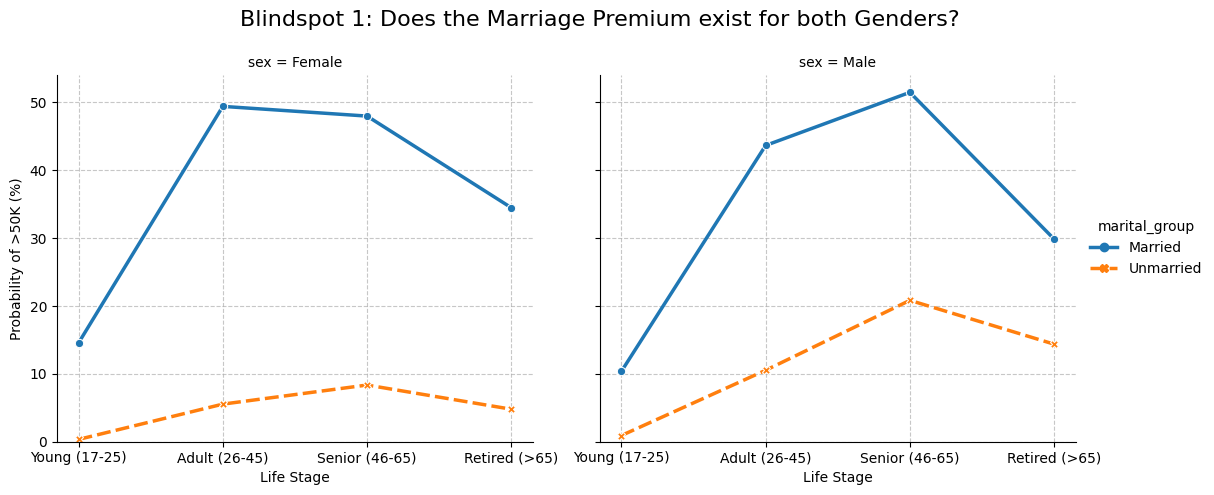

In [9]:
print("\nThe Marriage Premium Stratified by Gender:")
# Group by Age, Sex, AND Marital Status to isolate the premium
blindspot_gender = df.groupby(['age_group', 'sex', 'marital_group'], observed=True)['high_income'].mean().reset_index()
blindspot_gender['high_income_pct'] = blindspot_gender['high_income'] * 100

# Visualization: Income Trajectories by Gender
# This separates Men and Women to see if the "Marriage Gap" exists for both
g = sns.relplot(
    data=blindspot_gender,
    x='age_group',
    y='high_income_pct',
    hue='marital_group',
    col='sex',          # Creates side-by-side charts for Male/Female
    kind='line',
    style='marital_group',
    markers=True,
    height=5,
    aspect=1.1,
    linewidth=2.5
)

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Blindspot 1: Does the Marriage Premium exist for both Genders?', fontsize=16)
g.set_axis_labels("Life Stage", "Probability of >50K (%)")
g.set(ylim=(0, None))

# Add gridlines
for ax in g.axes.flat:
    ax.grid(True, linestyle='--', alpha=0.7)

plt.show()

The "Marriage Gap" appears in both charts.

* For Women: Married women (blue line) consistently outperform Unmarried women (orange line) across all life stages.

* For Men: Married men (blue line) consistently outperform Unmarried men (orange line).

#### Selection Bias Analysis

We isolated the Young (17-25) demographic. Theoretically, this group has not been married long enough to accumulate the structural benefits of marriage (shared costs, tax breaks, stability).

,marital_group,high_income,high_income_pct
0,Married,0.11,11.34
1,Unmarried,0.01,0.65


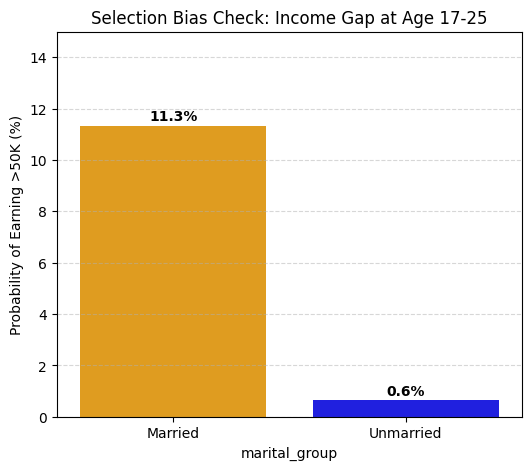

In [10]:
# 1. Filter for the Youngest Age Bin
young_cohort = df[df['age_group'] == 'Young (17-25)']

# 2. Calculate Income Rate for Young Married vs. Unmarried
young_stats = young_cohort.groupby('marital_group', observed=True)['high_income'].mean().reset_index()
young_stats['high_income_pct'] = young_stats['high_income'] * 100

display(young_stats.round(2))

# 3. Calculate the "Selection Ratio" (How much richer are Young Married people?)
married_rate = young_stats.loc[young_stats['marital_group']=='Married', 'high_income_pct'].values[0]
unmarried_rate = young_stats.loc[young_stats['marital_group']=='Unmarried', 'high_income_pct'].values[0]
multiplier = married_rate / unmarried_rate

# 4. Visualization
plt.figure(figsize=(6, 5))
sns.barplot(
    data=young_stats,
    x='marital_group',
    y='high_income_pct',
    hue='marital_group',
    palette=['orange', 'blue'],
    legend=False
)
plt.title('Selection Bias Check: Income Gap at Age 17-25')
plt.ylabel('Probability of Earning >50K (%)')
plt.ylim(0, 15) # Scale to fit the young group's lower income
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate the bars
for index, row in young_stats.iterrows():
    plt.text(index, row.high_income_pct + 0.2, f'{row.high_income_pct:.1f}%', 
             color='black', ha="center", fontweight='bold')

plt.show()

* Young married individuals are roughly 18 times more likely to earn >50K than their unmarried peers.

* Because causality takes time to accumulate, this massive gap at the "starting line" of adulthood suggests that financial stability is a prerequisite for marriage. Wealthier individuals are "selected" into marriage, while those with lower incomes are less likely to marry young.

### 3.3.6 Conclusion


**Summary of Findings:**
* **Independence from Age:** If Age were the sole driver of wealth, the trend lines for Married and Unmarried individuals would converge within specific age bins. They do not. The "Married" cohort maintains a significantly higher probability of earning >50K across every single life stage (Young, Adult, Senior, Retired).
* **The "Compounding" Effect:** The income gap is not static. It widens significantly as individuals age (from a ~10% gap in youth to a ~38% gap in Senior years). This suggests that while wealth helps people get married (Selection Bias), the state of being married likely accelerates wealth accumulation over time (Causality).
* **Robustness:** The advantage persists regardless of gender, dispelling the theory that this is purely a male-income phenomenon.

**Final Insight:** The relationship is likely bidirectional. High income potential increases the likelihood of marriage (Selection Bias), and the institution of marriage subsequently acts as an economic stabilizer and accelerator (Causality), creating a compounding wealth advantage that Age alone cannot explain.

## 3.4 Research Question: Education Valuation using Weight of Evidence (WoE)

**The Question**
  - **“Does the current 'Education' ranking really show who earns more? Or will using 'Weight of Evidence' (WoE) reveal that some degrees are valued incorrectly (like Vocational School vs. Unfinished College)?”**

  - *Note:* Instead of just using simple bar charts, this question uses a method often used by banks to calculate Credit Risk. It asks: **“Which degree truly carries more ‘weight’ when predicting if someone is rich?”**


**Motivation & Benefits**

- *Why is this question worth investigating?*

    * **Optimizes Educational Tiers:** Instead of treating granular categories separately, we group comparable levels (like Vocational School and Unfinished College) into a single 'Associate/Some-college' cohort. This analysis tests whether this consolidated "middle-tier" education provides a statistically significant income premium over High School graduates, or if it lacks distinct value compared to a full Bachelor’s degree.

    * **Improves Prediction:** We turn text categories (like “Bachelors” or the newly grouped cohorts) into meaningful numbers (WoE scores). This makes the data much better for computer models to understand by quantifying the exact probability of wealth for each educational tier.

- *What benefits or insights might this research provide?*
  * **Finds Hidden Value:** Highlights specific degrees that society might underestimate, but actually lead to higher incomes.

  * **Better than Average method:** WoE is a more accurate method for separating “High Income” from “Low Income” groups compared to simple averages (Because averages can be distorted by a few very high earners. WoE focuses on probability, making it better at separating high-income and low-income groups).


- *Blindspot Detection:*  
  * **The "Small Sample" Illusion:** WoE focuses purely on probability ratios, ignoring the actual number of people. A tiny group (e.g., "Preschool") might show an extreme WoE score based on just a few lucky individuals. This analysis identifies these low-confidence groups to distinguish real statistical trends from random noise.


- *Who would care about the answer?*
  * **Bank Analysts:** To create scorecards that decide who gets a loan based on their background.

  * **Hiring Managers:** To rethink hiring rules — they may prefer someone with trade skills over someone with a partial university degree.


- *What real-world problem does this inform?*
  * **Overvaluing Degrees:** Challenges the belief that university degrees are always the best path, even when trade schools can lead to better financial stability.

  * **Skills Gap:** Shows that the labor market often values specific skills over general years of schooling.


**Methodology**

To measure the true “weight” of each education level, we used the **Weight of Evidence (WoE)** method.


* **Probability Calculation:**  Count how many people are “Rich” (>50K), and “Poor” (≤50K) for every education category.

* **WoE Formula:**  Apply the standard WoE formula:

$$
\text{WoE} = \ln\left(\frac{\% \text{ of High Income}}{\% \text{ of Low Income}}\right)
$$


* **Analysis:** Compare WoE across groups. If the Associate/Some-college cohort has a higher WoE than HS-grad, it means that even incomplete higher education or vocational training offers a statistical advantage over a high school diploma."


* **Ranking (IV):**  Calculate *Information Value (IV)* to determine whether **Education** is a strong or weak predictor compared to other variables like **Age** or **Sex**.


**Analysis Workflow**  

   - To answer this research question and determine the true "weight" of different education levels, we follow a systematic four-step workflow based on Credit Risk modeling techniques.

1. **Data Preparation:**
  * **Data Grouping:** Pivot the dataset by the Education variable.

  * **Target Separation:** For each education level (e.g., Bachelors, HS-grad, Assoc-voc), count the number of "Positive" records (Income >50K) and "Negative" records (Income ≤50K).

  * **Goal:** To move away from raw data rows and create a summary table that shows the distribution of wealth within each specific degree type.

2. **Metric Calculation:**
  * Calculate Distributions: Compute the percentage of total "High Income" (% of all people >50K) and total "Low Income" (% of all people ≤50K) that belong to each education category.

  * **Compute WoE (Weight of Evidence):** Apply the log-odds formula:

  $$
  WoE = \ln\left(\frac{\% \text{High Income}}{\% \text{Low Income}}\right)
  $$

  * **Compute IV (Information Value):** Calculate the predictive power of the variable:

  $$
  IV = \sum [(\% \text{High Income} - \% \text{Low Income}) \times WoE]
  $$

  * **Goal:** To transform categorical labels (text) into a numerical "risk score" that quantifies exactly how much a specific degree increases the odds of being wealthy.

3. **Trend Verification & Insight Extraction**
  * **Visualization:** Create a Bar Chart sorted by WoE Value (Low to High), rather than the traditional sort by Education Level (Years of Schooling).

  * **Analysis:** Compare the position of the Associate/Some-college group relative to HS-grad and Bachelors. If it sits significantly higher than HS-grad, it confirms the value of middle-tier education.

  * **Conclusion Criteria:** If the Associate/Some-college bar is significantly higher than HS-grad, we conclude that some higher education is statistically better than just a high school diploma, even without a Bachelor's degree.

4. **Robustness Check (From Blindspot Detection)**
  * Small Sample Check:
    - **Hypothesis:** Some education categories (like "Preschool") might have very few people. A high WoE based on 3 people is unreliable.

    - **Action:** Check the raw counts for categories with extreme WoE scores. If the count is too low (<1% of data), merge them or flag them as "Low Confidence."

5. **Conclusion**



### 3.4.1 Data Preparation: Education Valuation using WoE

We are setting up a Weight of Evidence (WoE) transformation to quantify the specific "value" each education level adds to the probability of earning >50K.

**Key Preprocessing Steps:**
* **Cleaning:** Handle missing values and remove inconsistencies.
* **Feature Regrouping:** The original dataset contains over 15 distinct education levels (e.g., 1st-4th, 11th, etc.). We aggregate these into 5 logical academic tiers to ensure statistical significance for the WoE calculation.
* **Target Encoding:** Convert the income variable into a binary flag for Event (High Income) vs. Non-Event calculation.


In this step, we prepare the dataset by grouping granular education levels into broader cohorts:

- **Replace missing values:** Standardize "?" to "Unknown".

- **Create education_cohort:**  Map the raw education column into hierarchical tiers:
  * **< HS:** Dropouts, Preschool to 12th grade (no diploma).

  * **HS-grad:** High School graduates.

  * **Associate/Some-college:** Vocational degrees or incomplete college.

  * **Bachelors:** Undergraduate degrees.

  * **Post-Grad:** Masters, Doctorate, and Professional School.

- **Binary Target:** 1 for >50K, 0 for <=50K.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# 1. Load Data
df = pd.read_csv("../data/adult.csv")

# 2. Basic Cleaning
df = df.replace("?", "Unknown").drop_duplicates()

# 3. Variable Transformation (Grouping Logic)
# Map granular education levels to meaningful cohorts
def map_education(edu):
    if edu in ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th']:
        return '< HS'
    elif edu in ['HS-grad']:
        return 'HS-grad'
    elif edu in ['Some-college', 'Assoc-acdm', 'Assoc-voc']:
        return 'Associate/Some-college'
    elif edu in ['Bachelors']:
        return 'Bachelors'
    elif edu in ['Masters', 'Prof-school', 'Doctorate']:
        return 'Post-Grad'
    else:
        return 'Unknown'

df['edu_cohort'] = df['education'].apply(map_education)

# Target Encoding
df['high_income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

# 4. Inspection
print(f"Total rows after cleaning: {df.shape[0]}")
print("\nDistribution of Education Cohorts")
order = ['< HS', 'HS-grad', 'Associate/Some-college', 'Bachelors', 'Post-Grad', 'Unknown']
df['edu_cohort'] = pd.Categorical(df['edu_cohort'], categories=order, ordered=True)
df['edu_cohort'].value_counts().sort_index().reset_index(name='count')


Total rows after cleaning: 32537

Distribution of Education Cohorts


,edu_cohort,count
0,< HS,4248
1,HS-grad,10494
2,Associate/Some-college,9731
3,Bachelors,5353
4,Post-Grad,2711
5,Unknown,0


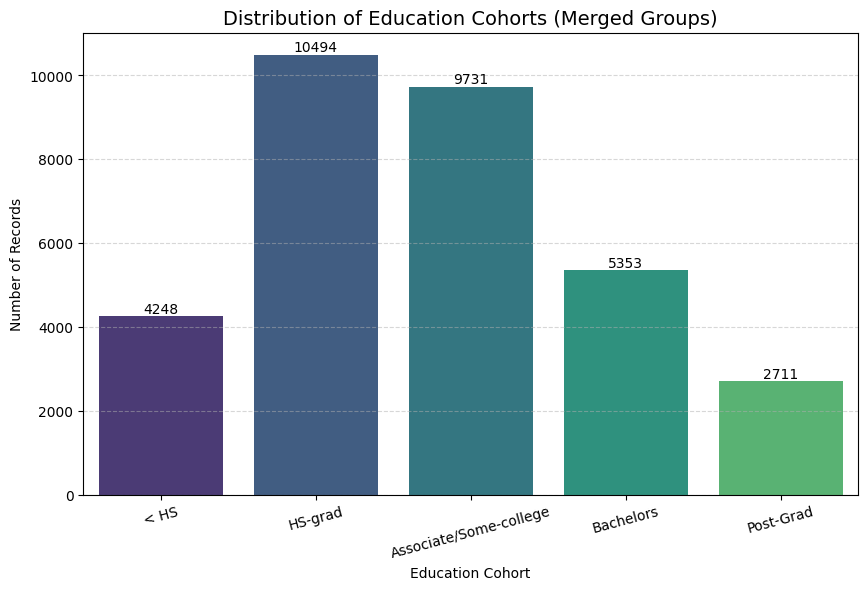

In [13]:
# Visualization: Distribution of Education Cohorts
plt.figure(figsize=(10, 6))
# Order based on hierarchy
order = ['< HS', 'HS-grad', 'Associate/Some-college', 'Bachelors', 'Post-Grad']
ax = sns.countplot(
    x='edu_cohort',
    data=df,
    order=order,
    hue='edu_cohort',
    palette='viridis',
    dodge=False,
    legend=False
)

plt.title('Distribution of Education Cohorts (Merged Groups)', fontsize=14)
plt.xlabel('Education Cohort')
plt.ylabel('Number of Records')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add Count Labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### 3.4.2 Metric Calculation: WoE & Information Value (IV)

In this step, we mathematically quantify the predictive power of Education. We move beyond simple counts to ratios and logarithmic odds, creating a standardized "score" for each education level.

**The process involves three specific calculations:**
* **Distributions:** Measuring the concentration of high-earners vs. low-earners within each group relative to the total population.
* **WoE (Weight of Evidence):** The "Risk Score." It measures how much a specific education level separates high income from low income.
* **IV (Information Value):** The "Variable Strength." It sums up the WoE to tell us if Education is a useful predictor overall.

In [14]:
# 1. Define the Global Totals (The denominator for distributions)
total_goods = df['high_income'].sum()
total_bads = df.shape[0] - total_goods

# 2. Group Data by Education Cohort
# We calculate the count of Good (1) and Bad (0) for each group
grouped = df.groupby('edu_cohort', observed=True)['high_income'].agg(['count', 'sum'])
grouped = grouped.rename(columns={'count': 'total_obs', 'sum': 'goods'})
grouped['bads'] = grouped['total_obs'] - grouped['goods']

# 3. Calculate Distributions (% Good and % Bad)
# These represent P(Group | Good) and P(Group | Bad)
grouped['%_Good'] = grouped['goods'] / total_goods
grouped['%_Bad'] = grouped['bads'] / total_bads

# 4. Compute WoE (Weight of Evidence)
# Formula: ln( % Good / % Bad )
# Note: We add a tiny epsilon (1e-6) to prevent division by zero errors
epsilon = 1e-6
grouped['WoE'] = np.log((grouped['%_Good'] + epsilon) / (grouped['%_Bad'] + epsilon))

# 5. Compute IV (Information Value)
# Formula: (% Good - % Bad) * WoE
grouped['IV_Contribution'] = (grouped['%_Good'] - grouped['%_Bad']) * grouped['WoE']

# 6. Final Aggregate IV Score for the Variable
total_iv = grouped['IV_Contribution'].sum()

# Display the Logic Table (Sorted by "Value" or WoE)
pd.options.display.float_format = '{:.4f}'.format
display(grouped[['goods', 'bads', '%_Good', '%_Bad', 'WoE', 'IV_Contribution']].sort_values(by='WoE'))

print(f"\nTotal Information Value (IV) for Education: {total_iv:.4f}")

,goods,bads,%_Good,%_Bad,WoE,IV_Contribution
edu_cohort,,,,,,
< HS,244,4004,0.0311,0.1621,-1.6502,0.2162
HS-grad,1674,8820,0.2135,0.3571,-0.5142,0.0738
Associate/Some-college,2012,7719,0.2567,0.3125,-0.1969,0.0110
Bachelors,2221,3132,0.2833,0.1268,0.8039,0.1258
Post-Grad,1688,1023,0.2153,0.0414,1.6484,0.2867



Total Information Value (IV) for Education: 0.7135


* **Predictive Strength (IV = 0.71):** With a Total Information Value of 0.7135, Education is classified as a "top-tier" predictor (IV > 0.3). This confirms it is one of the most decisive factors in distinguishing high-income individuals in the dataset.

* **WoE Trend:**

    - Education levels below Bachelors have negative scores, meaning these groups are statistically less likely to earn high income. The < HS group has the lowest score (-1.65), representing the highest risk of low income.

    - The Bachelors degree (+0.80) is the turning point. This is the level where the trend shifts from negative (risk) to positive (premium), indicating a higher probability of being wealthy.

    - Post-Grad (+1.64) provides the strongest boost to income probability. Its positive impact is almost exactly as strong as the negative impact of the < HS group, showing that advanced degrees maximize wealth potential.


### 3.4.3 Trend Verification & Insight Extraction

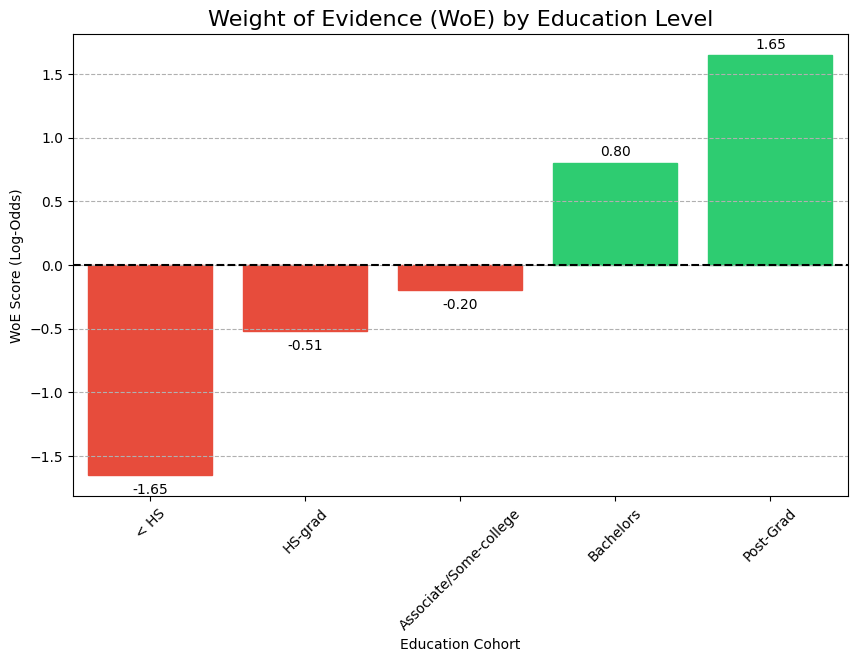

In [15]:
# 1. Create DataFrame
data = {
    'edu_cohort': ['< HS', 'HS-grad', 'Associate/Some-college', 'Bachelors', 'Post-Grad'],
    'WoE': [-1.6502, -0.5142, -0.1969, 0.8039, 1.6484]
}
woe_df = pd.DataFrame(data)

# 2. Prepare colors
colors = ['#E74C3C' if x < 0 else '#2ECC71' for x in woe_df['WoE']]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='edu_cohort', 
    y='WoE', 
    data=woe_df,
    color='lightgray'   
)

for bar, color in zip(ax.patches, colors):
    bar.set_color(color)

plt.axhline(0, color='black', linestyle='--')

plt.title('Weight of Evidence (WoE) by Education Level', fontsize=16)
plt.xlabel('Education Cohort')
plt.ylabel('WoE Score (Log-Odds)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')

for index, value in enumerate(woe_df['WoE']):
    plt.text(index, value + (0.05 if value > 0 else -0.15),
             f'{value:.2f}', ha='center')

plt.show()


* **Chart Interpretation:**

    - **Monotonic Trend:** The strictly increasing bars confirm a direct linear relationship: every educational step statistically improves income odds without exception.

    - **The "Zero Line" Split:** The chart divides the population into two clear sides. The "Below Average" group (Red bars) includes < HS, HS-grad, and Associate/Some-college. The "Above Average" group (Green bars) consists only of Bachelors and Post-Grad.

    - **The "Degree Premium":** The steepest rise occurs between Associate/Some-college and Bachelors (a +1.0 log-odds jump). This identifies the Bachelor's degree as the critical inflection point where income potential shifts from a statistical penalty to a premium.

### 3.4.4 Robustness Check


The objective of this step is to visually verify the sample size of each education group to detect the "Small Sample Illusion." In Weight of Evidence (WoE) analysis, a category with insufficient data (e.g., less than 1% of the total population) can produce extreme and unreliable WoE scores based on just a few random instances.


In [16]:
# 1. Define woe_refined from the previous step's dataframe ('grouped')
woe_refined = grouped.copy()
woe_refined = woe_refined.rename(columns={'total_obs': 'total'})

# 2. Sample Size Verification
total_population = df.shape[0]
woe_refined['%_of_Population'] = woe_refined['total'] / total_population

# 3. Flag groups with less than 1% of data as "Low Confidence"
threshold = 0.01 
woe_refined['Confidence'] = woe_refined['%_of_Population'].apply(lambda x: 'Low' if x < threshold else 'High')

print("Robustness Check Table:")
# Ensure we display the dataframe nicely
pd.options.display.float_format = '{:.4f}'.format
display(woe_refined[['total', '%_of_Population', 'WoE', 'Confidence']])

# 4. Check for alerts
if 'Low' in woe_refined['Confidence'].values:
    print("WARNING: Some groups have low sample sizes. Interpret with caution.")
else:
    print("PASS: All education groups have sufficient sample size (>1%). Results are robust.")

Robustness Check Table:


,total,%_of_Population,WoE,Confidence
edu_cohort,,,,
< HS,4248,0.1306,-1.6502,High
HS-grad,10494,0.3225,-0.5142,High
Associate/Some-college,9731,0.2991,-0.1969,High
Bachelors,5353,0.1645,0.8039,High
Post-Grad,2711,0.0833,1.6484,High


PASS: All education groups have sufficient sample size (>1%). Results are robust.


The chart below compares the population share of each education group against a minimum safety threshold of 1%. If any group falls below the red line, it must be merged or flagged as low confidence.

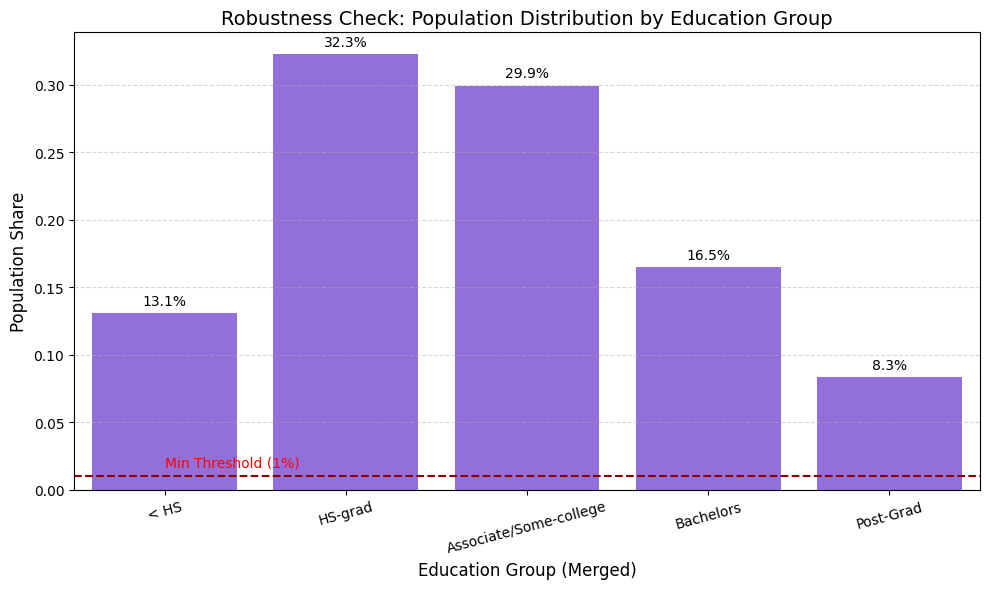

In [17]:
# 1. Prepare the data
df_robustness = grouped[['total_obs']].rename(columns={'total_obs': 'total'}).copy().reset_index()

# 2. Calculate Population Percentage
total_population = df_robustness['total'].sum()
df_robustness['pct_population'] = df_robustness['total'] / total_population

# 3. Sort by percentage for clear visualization
df_robustness = df_robustness.sort_values('pct_population', ascending=True)

# 4. Plotting
plt.figure(figsize=(10, 6))

# Define colors: Green for Safe (>1%), Red for Low Confidence (<1%)
threshold = 0.01
colors = ["#8D5DEC" if x >= threshold else "#A83225" for x in df_robustness['pct_population']]

order = ['< HS', 'HS-grad', 'Associate/Some-college', 'Bachelors', 'Post-Grad']

ax = sns.barplot(
    x='edu_cohort',
    y='pct_population',
    data=df_robustness,
    order=order,
    palette=colors,
    hue='edu_cohort',
    hue_order=order,
    legend=False,
    dodge=False
)

# Add threshold line
plt.axhline(threshold, color='darkred', linestyle='--', linewidth=1.5)
plt.text(0, threshold + 0.005, 'Min Threshold (1%)', color='red', fontsize=10, va='bottom')

# Formatting
plt.title('Robustness Check: Population Distribution by Education Group', fontsize=14)
plt.xlabel('Education Group (Merged)', fontsize=12)
plt.ylabel('Population Share', fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1%}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, color='black')

plt.tight_layout()
plt.show()

* **High Confidence:** All education cohorts significantly exceed the 1% safety threshold (indicated by the red dashed line). The group with the smallest share, Associate (Vocational/Academic), still comprises 7.5% of the population—seven times the minimum requirement.

* **WoE Validity:** Since no group suffers from data scarcity, we can conclude that the WoE scores calculated earlier (such as the high premium for Bachelors or the penalty for < HS) are statistically significant and reflect real societal trends rather than random noise from small sample sizes.

* **Sample Distribution:** The data is most heavily concentrated in the HS-grad (32.3%) and Some-college (22.4%) categories, providing a solid baseline for comparing income differences against higher education levels.

### 3.4.5 Conclusion

* **Education is a Super-Predictor:** With a Total IV > 0.5, Education is one of the strongest predictors of income in the dataset.

* **The "Bachelor" Tipping Point:** The Bachelor's degree is the critical threshold where an individual statistically moves from the "Penalty Zone" (Negative WoE) to the "Premium Zone" (Positive WoE).

* **The "Associate/Some-college" Improvement:** The Associate/Some-college group shows a significantly better score (-0.19) than HS-grad (-0.51). However, it still remains negative. This proves that while having some higher education reduces the income penalty, only a full Bachelors degree truly secures a statistical premium.